# Bicubic Interpolation

**Bicubic Interpolation** is a more advanced image resizing technique that uses cubic polynomials to compute the value of each pixel in the resized image. It considers the closest 16 pixels (a 4x4 grid) around each pixel to produce smoother and higher-quality results compared to both Nearest Neighbor and Bilinear Interpolation.

## Mathematical Explanation

1. **Original Image and Resizing:**
   - Let $( I )$ be the original image with dimensions $( H \times W )$ (Height × Width).
   - We aim to resize $( I )$ to a new image with dimensions $( H' \times W' )$, where $( H' )$ and $( W' )$ are the new dimensions.

2. **Scaling Factors:**
   - Define scaling factors $( \alpha )$ and $( \beta )$ for the height and width dimensions:
     $$
     \alpha = \frac{H'}{H}
     $$
     $$
     \beta = \frac{W'}{W}
     $$
   - These scaling factors represent how much larger the resized image will be compared to the original image.

3. **Pixel Mapping:**
   - For a pixel at coordinates $( (x', y') )$ in the resized image, calculate the corresponding position in the original image:
     $$
     x = \frac{x'}{\alpha}
     $$
     $$
     y = \frac{y'}{\beta}
     $$
   - $( (x, y) )$ is typically a non-integer value.

4. **Bicubic Interpolation:**
   - To compute the pixel value at $( (x', y') )$, find the 16 surrounding pixels in a 4x4 grid:
     - These are the pixels located at $( (i, j) )$ where $( i )$ and $( j )$ range from $( \lfloor x \rfloor - 1 )$ to $( \lceil x \rceil + 1 )$ and $( \lfloor y \rfloor - 1 )$ to $( \lceil y \rceil + 1 )$.

   - Compute the weight for each surrounding pixel using cubic convolution kernels. The bicubic interpolation formula involves a cubic polynomial defined as:
     $$
     I'(x', y') = \sum_{i=-1}^{2} \sum_{j=-1}^{2} w(i, x) \cdot w(j, y) \cdot I(x+i, y+j)
     $$
   - The weight function $( w(t, u) )$ is typically defined by:
     $$
     w(t, u) = \begin{cases}
     (a + 2) |t|^3 - (a + 3) |t|^2 + 1 & \text{if } 0 \leq |t| < 1 \\
     a |t|^3 - 5a |t|^2 + 8a |t| - 4a & \text{if } 1 \leq |t| < 2 \\
     0 & \text{otherwise}
     \end{cases}
     $$
   - Here, $( a )$ is a parameter typically set to -0.5.

## Practical Considerations

1. **Smoothing and Quality:**
   - Bicubic interpolation provides high-quality results with smoother gradients and fewer artifacts compared to Nearest Neighbor and Bilinear interpolation.

2. **Computational Complexity:**
   - It is more computationally intensive than Nearest Neighbor and Bilinear interpolation because it involves more complex calculations and a larger set of neighboring pixels.

3. **Applications:**
   - Ideal for applications where high-quality image scaling is required, such as in photo editing and high-resolution displays.

## Example Code

Here is a Python code snippet using the `PIL` library to perform Bicubic Interpolation for upsampling:

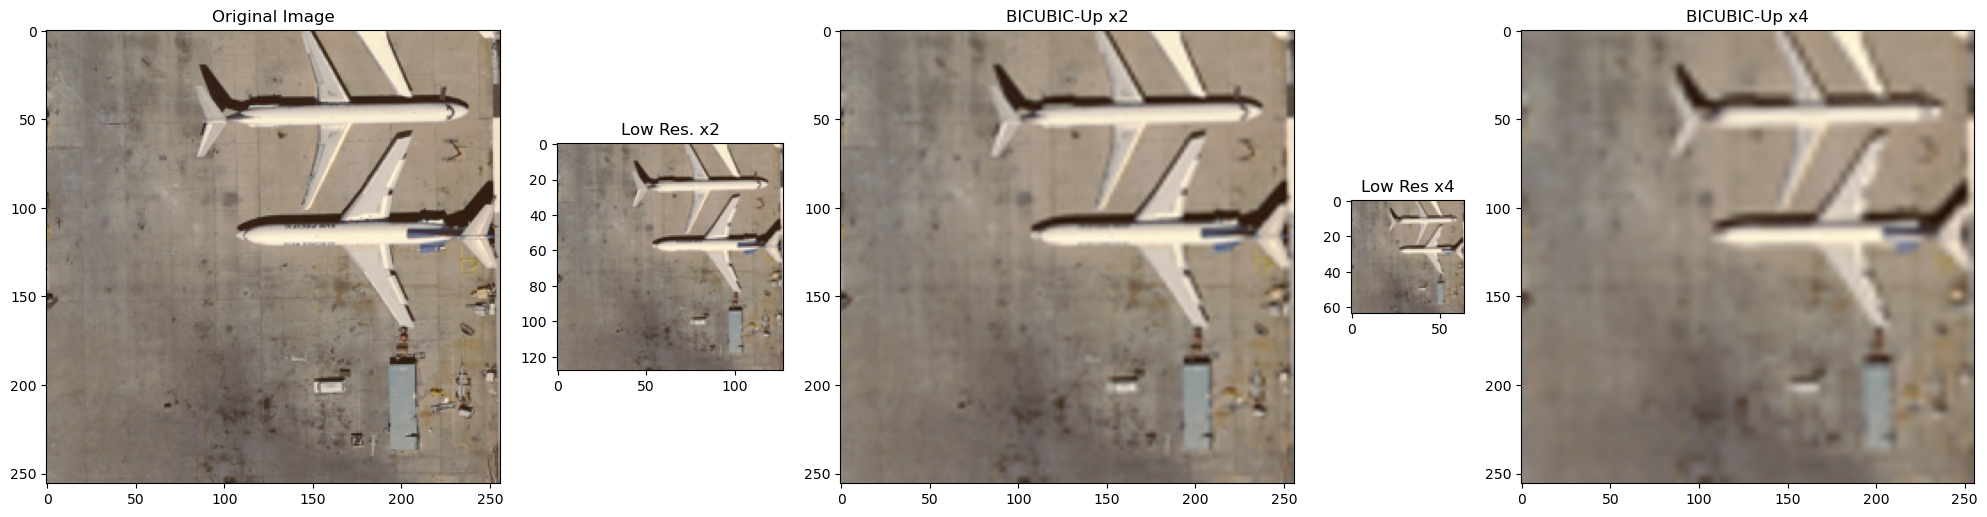

In [1]:
from PIL import Image
import matplotlib.pyplot as plt

def bicubic_upsample(image, scale_factor):
    # Resize the image using bicubic interpolation
    return image.resize(
        (int(image.width * scale_factor), int(image.height * scale_factor)), 
        Image.BICUBIC
    )

# Load an image
image_hr = Image.open('./images/image_hr.png').convert('RGB')
image_lr_2 = Image.open('./images/image_lr_2.png').convert('RGB')
image_lr_4 = Image.open('./images/image_lr_4.png').convert('RGB')

# Perform upsampling with a scale factor of 2
scaled_image_2 = bicubic_upsample(image_lr_2, scale_factor=2)
scaled_image_4 = bicubic_upsample(image_lr_4, scale_factor=4)

# Create a figure with subplots
fig, axs = plt.subplots(1, 5, figsize=(20, 5), gridspec_kw={'width_ratios': [1, 0.5, 1, 0.25, 1]})

# Display each image in a subplot
axs[0].imshow(image_hr)
axs[0].set_title('Original Image')
axs[0].axis('on')

axs[1].imshow(image_lr_2)
axs[1].set_title('Low Res. x2')
axs[1].axis('on')

axs[2].imshow(scaled_image_2)
axs[2].set_title('BICUBIC-Up x2')
axs[2].axis('on')

axs[3].imshow(image_lr_4)
axs[3].set_title('Low Res x4')
axs[3].axis('on')

axs[4].imshow(scaled_image_4)
axs[4].set_title('BICUBIC-Up x4')
axs[4].axis('on')

# Adjust the layout to fit the images properly
plt.tight_layout()
plt.show()